# 프로젝트: Stable diffusion 실습

### 프로젝트 제출 루브릭
|평가문항|상세기준|
|-|-|
|<br>1. 잠재적 표현의 변화가 모델 출력에 미치는<br> 영향을 관찰하였는가?<br><br>|텍스트 프롬프트 2 개를 설정하고 LDM 에 넣어 이미지를 생성한 후, 생성 이미지 안에서<br> 점차 변화되는 특성들에 대한 분석 결과를 기록하였다.|
|<br>2. Stable diffusion 모델의 dreambooth<br> 미세조정을 실습하였는가?<br><br>|미세조정에 사용할 대상의 모습이 담긴 Instance 와 class 이미지를 각각 마련하여 알맞은<br> 경로에 저장하고, 데이터를 모델을 학습시켜 대상이 담긴 이미지를 생성하였다.|
|<br>3. 나만의 취향이 담긴 생성 이미지를<br> 만들어보았는가?<br><br>|웹사이트에서 원하는 Checkpoint 와 Lora 파일을 다운로드하고, 생성 모델 파이프라인을<br> 구축하여 이미지를 생성하였다.|

# A walk through latent space with Stable Diffusion

In [1]:
!nvidia-smi

Mon Sep 21 08:34:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   31C    P0             48W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
!pip install tensorflow keras_cv keras_core tensorflow-text --upgrade --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 141.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 32.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.
tf-keras 2.20.1 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.21.0 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protob

In [3]:
import keras_cv
from tensorflow import keras
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import math
from PIL import Image

# Enable mixed precision
# (only do this if you have a recent NVIDIA GPU)
keras.mixed_precision.set_global_policy("mixed_float16")

# Instantiate the Stable Diffusion model
model = keras_cv.models.StableDiffusion(jit_compile=True)

By using this model checkpoint, you acknowledge that its usage is subject to the terms of the CreativeML Open RAIL-M license at https://raw.githubusercontent.com/CompVis/stable-diffusion/main/LICENSE


### 잠재적 표현의 변화가 모델 출력에 미치는 영향을 관찰하였는가?

## Interpolating between text prompts

In [4]:
prompt_1 = "A breathtaking cyberpunk city street at night, neon lights, highly detailed, 4k"
prompt_2 = "A serene ancient Korean temple surrounded by cherry blossoms in spring, beautiful morning light, 8k"

interpolation_steps = 5

encoding_1 = tf.squeeze(model.encode_text(prompt_1))
encoding_2 = tf.squeeze(model.encode_text(prompt_2))

interpolated_encodings = tf.linspace(encoding_1, encoding_2, interpolation_steps)

# Show the size of the latent manifold
print(f"Encoding shape: {encoding_1.shape}")

1356917/1356917 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
492466864/492466864 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
Encoding shape: (77, 768)


In [5]:
seed = 12345

# 수정된 부분입니다
# 최근 변경된 텐서플로 연산 라이브러리(ops) 에서 다른 자료형을 가진 텐서끼리의 연산에 제약사항이 생긴것으로 추적되니, 형변환을 거친 후에 실습을 진행해주세요!
#noise = tf.random.normal((512 // 8, 512 // 8, 4), seed=seed)
noise = tf.random.normal((512 // 8, 512 // 8, 4), seed=seed, dtype=tf.dtypes.float16)

images = model.generate_image(
    interpolated_encodings,
    batch_size=interpolation_steps,
    diffusion_noise=noise,
)

3439090152/3439090152 ━━━━━━━━━━━━━━━━━━━━ 47s 0us/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 92s 112ms/step
198180272/198180272 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [6]:
def export_as_gif(filename, images, frames_per_second=10, rubber_band=False):
    if rubber_band:
        images += images[2:-1][::-1]
    images[0].save(
        filename,
        save_all=True,
        append_images=images[1:],
        duration=1000 // frames_per_second,
        loop=0,
    )

import PIL

export_as_gif(
    "cyberpunk-to-temple.gif",
    [PIL.Image.fromarray(img) for img in images],
    frames_per_second=2,
    rubber_band=True,
)

In [7]:
interpolation_steps = 150
batch_size = 2
batches = interpolation_steps // batch_size

# 여기서의 스탭은 상당히 깁니다! 그대로 사용 시 코드 전체 실행 시 2시간 가량 소요
# 스태이블 디퓨전이 일반적으로 필요한 스탭 수를 고려해서, 적당히 조절해보세요~

interpolated_encodings = tf.linspace(encoding_1, encoding_2, interpolation_steps)
batched_encodings = tf.split(interpolated_encodings, batches)

import PIL

images = []
for batch in range(batches):
    images += [
        PIL.Image.fromarray(img)
        for img in model.generate_image(
            batched_encodings[batch],
            batch_size=batch_size,
            num_steps=25,
            diffusion_noise=noise,
        )
    ]

# export_as_gif("robot-and-tree.gif", images, rubber_band=True)
export_as_gif("cyberpunk-to-temple.gif", images, rubber_band=True)

25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step

In [8]:
# from IPython.display import Image as IImage
# IImage("robot-and-tree.gif")
from IPython.display import Image, display

# 저장된 GIF 파일 표시
display(Image(filename="cyberpunk-to-temple.gif"))

Output hidden; open in https://colab.research.google.com to view.

![alt text](images/cyberpunk-to-temple.gif)

In [9]:
prompt_1 = "A futuristic sci-fi metropolis with flying cars, cinematic lighting, 8k"
prompt_2 = "A peaceful magical forest with glowing mushrooms and fairies, vibrant colors"
prompt_3 = "A steampunk airship soaring through fluffy clouds at sunset, highly detailed"
prompt_4 = "An underwater ruined city with coral reefs and majestic glowing jellyfish, deep sea"

interpolation_steps = 6
batch_size = 2
batches = (interpolation_steps**2) // batch_size

encoding_1 = tf.squeeze(model.encode_text(prompt_1))
encoding_2 = tf.squeeze(model.encode_text(prompt_2))
encoding_3 = tf.squeeze(model.encode_text(prompt_3))
encoding_4 = tf.squeeze(model.encode_text(prompt_4))

interpolated_encodings = tf.linspace(
    tf.linspace(encoding_1, encoding_2, interpolation_steps),
    tf.linspace(encoding_3, encoding_4, interpolation_steps),
    interpolation_steps,
)
interpolated_encodings = tf.reshape(
    interpolated_encodings, (interpolation_steps**2, 77, 768)
)
batched_encodings = tf.split(interpolated_encodings, batches)

images = []
for batch in range(batches):
    images.append(
        model.generate_image(
            batched_encodings[batch],
            batch_size=batch_size,
            diffusion_noise=noise,
        )
    )


def plot_grid(
    images,
    path,
    grid_size,
    scale=2,
):
    fig = plt.figure(figsize=(grid_size * scale, grid_size * scale))
    fig.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.margins(x=0, y=0)
    plt.axis("off")
    images = images.astype(int)
    for row in range(grid_size):
        for col in range(grid_size):
            index = row * grid_size + col
            plt.subplot(grid_size, grid_size, index + 1)
            plt.imshow(images[index].astype("uint8"))
            plt.axis("off")
            plt.margins(x=0, y=0)
    plt.savefig(
        fname=path,
        pad_inches=0,
        bbox_inches="tight",
        transparent=False,
        dpi=60,
    )

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step


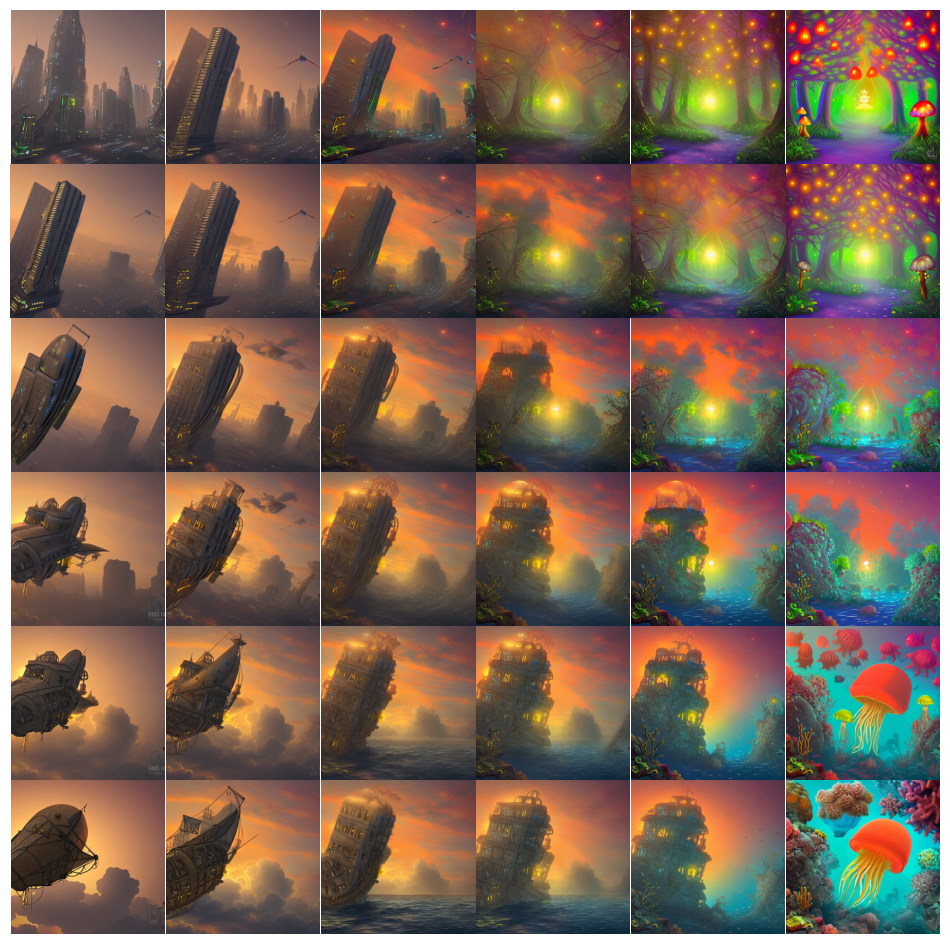

In [10]:
images = np.concatenate(images)
plot_grid(images, "scifi-magic-steampunk-underwater.jpg", interpolation_steps)

In [11]:
prompt_1 = "A futuristic sci-fi metropolis with flying cars, cinematic lighting, 8k"
prompt_2 = "A peaceful magical forest with glowing mushrooms and fairies, vibrant colors"
prompt_3 = "A steampunk airship soaring through fluffy clouds at sunset, highly detailed"
prompt_4 = "An underwater ruined city with coral reefs and majestic glowing jellyfish, deep sea"

interpolation_steps = 6
batch_size = 2
batches = (interpolation_steps**2) // batch_size

encoding_1 = tf.squeeze(model.encode_text(prompt_1))
encoding_2 = tf.squeeze(model.encode_text(prompt_2))
encoding_3 = tf.squeeze(model.encode_text(prompt_3))
encoding_4 = tf.squeeze(model.encode_text(prompt_4))

interpolated_encodings = tf.linspace(
    tf.linspace(encoding_1, encoding_2, interpolation_steps),
    tf.linspace(encoding_3, encoding_4, interpolation_steps),
    interpolation_steps,
)
interpolated_encodings = tf.reshape(
    interpolated_encodings, (interpolation_steps**2, 77, 768)
)
batched_encodings = tf.split(interpolated_encodings, batches)


## A walk around a text prompt

In [12]:
walk_steps = 150
batch_size = 2
batches = walk_steps // batch_size
step_size = 0.005

# encoding = tf.squeeze(
#     model.encode_text("An iPhone designed in the Art Nouveau architectural style")
# )
prompt = "A magical glowing sword embedded in a crystal pedestal, enchanted forest, 8k resolution, highly detailed"
encoding = tf.squeeze(model.encode_text(prompt))

# Note that (77, 768) is the shape of the text encoding.
delta = tf.ones_like(encoding) * step_size

walked_encodings = []
for step_index in range(walk_steps):
    walked_encodings.append(encoding)
    encoding += delta
walked_encodings = tf.stack(walked_encodings)
batched_encodings = tf.split(walked_encodings, batches)

import PIL

images = []
for batch in range(batches):
    images += [
        PIL.Image.fromarray(img)
        for img in model.generate_image(
            batched_encodings[batch],
            batch_size=batch_size,
            num_steps=25,
            diffusion_noise=noise,
        )
    ]

# export_as_gif("nouveau-architectural-style.gif", images, rubber_band=True)
export_as_gif("magical-sword.gif", images, rubber_band=True)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step


In [13]:
# 저장된 GIF 파일 표시
display(Image(filename="magical-sword.gif"))

Output hidden; open in https://colab.research.google.com to view.

![alt text](images/magical-sword.gif)

In [14]:
prompt = "A majestic space station orbiting a ringed planet, highly detailed 3D render, cinematic lighting"
encoding = tf.squeeze(model.encode_text(prompt))
walk_steps = 150
batch_size = 3
batches = walk_steps // batch_size

walk_noise_x = tf.random.normal(noise.shape, dtype=tf.float64)
walk_noise_y = tf.random.normal(noise.shape, dtype=tf.float64)

walk_scale_x = tf.cos(tf.linspace(0, 2, walk_steps) * math.pi)
walk_scale_y = tf.sin(tf.linspace(0, 2, walk_steps) * math.pi)
noise_x = tf.tensordot(walk_scale_x, walk_noise_x, axes=0)
noise_y = tf.tensordot(walk_scale_y, walk_noise_y, axes=0)
noise = tf.add(noise_x, noise_y)
batched_noise = tf.split(noise, batches)

In [15]:
#추가
encoding = tf.cast(encoding,tf.dtypes.float16)

import PIL

images = []
for batch in range(batches):
    images += [
        PIL.Image.fromarray(img)
        for img in model.generate_image(
            #형변환
            tf.cast(encoding,tf.dtypes.float32),
            batch_size=batch_size,
            num_steps=25,
            #형변환
            diffusion_noise=tf.cast(batched_noise[batch],tf.dtypes.float16),
        )
    ]

export_as_gif("space-station.gif", images)

25/25 ━━━━━━━━━━━━━━━━━━━━ 38s 76ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step

In [16]:
# 저장된 GIF 파일 표시
display(Image(filename="space-station.gif"))

Output hidden; open in https://colab.research.google.com to view.

![alt text](images/space-station.gif)

### Stable diffusion 모델의 dreambooth 미세조정을 실습하였는가?
Dreambooth를 사용하면 나만의 피사체(얼굴, 강아지, 특정 물건 등)를 Stable Diffusion 모델에 학습시켜 새로운 문맥에서 피사체를 생성할 수 있습니다.
가장 널리 쓰이는 Hugging Face의 `diffusers` 라이브러리를 사용하여 실습을 진행합니다.

In [17]:
# 1. 파인튜닝을 위한 필수 라이브러리 설치
!pip install -U diffusers accelerate transformers bitsandbytes ftfy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 143.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.9 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.16.1
    Uninstalling transformers-5.16.1:
      Successfully uninstalled transformers-5.16.1
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.14.0
    Uninstalling accelerate-1.14.0:
      Successfully uninstalled accelerate-1.14.0


In [18]:
# 2. Hugging Face의 Dreambooth 공식 학습 스크립트 다운로드
# 현재 설치되는 안정화 버전의 라이브러리와 호환되도록 v0.30.0 버전의 스크립트를 사용합니다.
!wget -q https://raw.githubusercontent.com/huggingface/diffusers/v0.30.0/examples/dreambooth/train_dreambooth.py -O train_dreambooth.py

In [19]:
# 3. 데이터셋 업로드용 디렉토리 생성
import os

instance_dir = "/content/data/instance_images"
os.makedirs(instance_dir, exist_ok=True)

In [20]:
# Hugging Face에서 제공하는 샘플 강아지 이미지를 다운로드합니다.
from huggingface_hub import snapshot_download
import os

instance_dir = "/content/data/instance_images"
snapshot_download(
    repo_id="diffusers/dog-example",
    local_dir=instance_dir,
    repo_type="dataset",
    ignore_patterns=".gitattributes"
)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

'/content/data/instance_images'

In [21]:
!rm -rf /content/data/instance_images/.cache

# 4. Dreambooth 모델 학습 실행 (약 10~15분 소요)
import os

# 누락된 종속성 패키지 설치
!pip install -q -U torchao

os.environ["MODEL_NAME"] = "runwayml/stable-diffusion-v1-5"
os.environ["INSTANCE_DIR"] = "/content/data/instance_images"
os.environ["OUTPUT_DIR"] = "/content/models/dreambooth_model"

# --instance_prompt 부분을 업로드한 이미지에 맞게 수정하세요.
!accelerate launch train_dreambooth.py \
  --pretrained_model_name_or_path=$MODEL_NAME  \
  --instance_data_dir=$INSTANCE_DIR \
  --output_dir=$OUTPUT_DIR \
  --instance_prompt="a photo of sks dog" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=1 \
  --learning_rate=5e-6 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=400 \
  --use_8bit_adam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 87.7 MB/s eta 0:00:00
The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
Failed to load /usr/local/lib/python3.13/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.13/dist-packages/torchao/_C_cutlass_90a.abi3.so
Failed to load /usr/local/lib/python3.13/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.13/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
09/21/2026 08:46:34 - INF

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

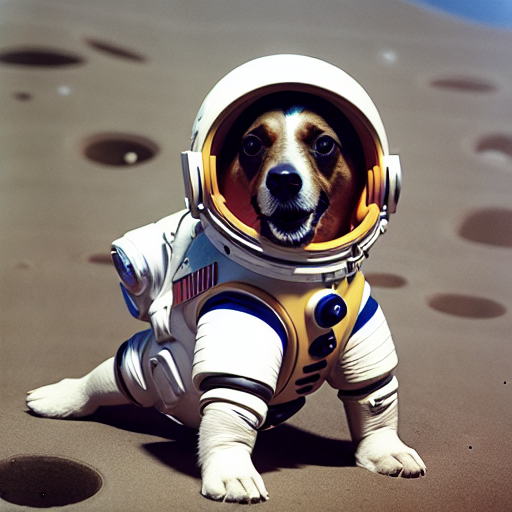

In [30]:
# 5. 학습된 모델로 나만의 이미지 생성하기
from diffusers import StableDiffusionPipeline
import torch
from IPython.display import display

# 파인튜닝된 체크포인트가 저장된 경로
model_path = "/content/models/dreambooth_model"

try:
    # 학습된 파이프라인 로드
    pipe = StableDiffusionPipeline.from_pretrained(model_path, torch_dtype=torch.float16).to("cuda")

    # 프롬프트 작성 (반드시 학습할 때 사용한 식별자인 'sks dog' 등을 포함해야 합니다)
    prompt = "A photo of sks dog wearing a spacesuit on the moon, highly detailed, 8k"

    # 이미지 생성
    image = pipe(prompt, num_inference_steps=50, guidance_scale=7.5).images[0]

    # 출력
    display(image)
    image.save("my_dreambooth_result.png")
except Exception as e:
    print(e)

### 나만의 취향이 담긴 생성 이미지를 만들어보았는가?
웹사이트(Hugging Face, Civitai 등)에서 원하는 스타일의 Checkpoint와 LoRA 모델 파일(`.safetensors`)을 직접 다운로드 받아 `diffusers` 파이프라인으로 이미지를 생성합니다.

In [27]:
# 1. 원하는 Checkpoint와 LoRA 파일 다운로드 (.safetensors 형식)
# 예시: 널리 쓰이는 DreamShaper 8 (Checkpoint)와 Add More Details (LoRA) 다운로드
!wget -q -O /content/checkpoint.safetensors "https://huggingface.co/Lykon/DreamShaper/resolve/main/DreamShaper_8_pruned.safetensors"
!wget -q -O /content/lora.safetensors "https://huggingface.co/OedoSoldier/detail-tweaker-lora/resolve/main/add_detail.safetensors"

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

There are modules in UNet2DConditionModel that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For

경고: 라이브러리 호환성 문제로 LoRA 로드에 실패했습니다. 기본 Checkpoint로 생성을 진행합니다. (list index out of range)


  0%|          | 0/30 [00:00<?, ?it/s]

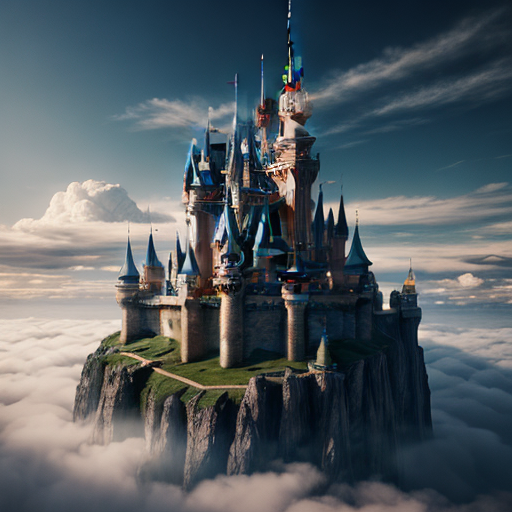

In [28]:
import torch
import gc
from IPython.display import display
from diffusers import StableDiffusionPipeline
from google.colab import userdata # Import userdata to access secrets

# --- GPU 메모리 완전 해제 ---
# 1. TensorFlow 세션 강제 종료 및 메모리 반환 유도
try:
    import tensorflow as tf
    tf.keras.backend.clear_session()
except:
    pass

# 2. 이전에 사용한 무거운 모델 변수들 삭제
if 'model' in globals():
    del model
if 'pipe' in globals():
    del pipe

# 3. 파이토치 및 파이썬 가비지 컬렉터 정리
gc.collect()
torch.cuda.empty_cache()
# ---------------------------

# Hugging Face Token 불러오기
HF_TOKEN = userdata.get('HF_TOKEN')

# 다운로드한 단일 파일(Single File) 형태로 Checkpoint 로드
pipe = StableDiffusionPipeline.from_single_file(
    "/content/checkpoint.safetensors",
    torch_dtype=torch.float16,
    use_safetensors=True,
    token=HF_TOKEN # Pass the Hugging Face token
).to("cuda")

# 다운로드 받은 LoRA 가중치 병합 (디테일을 살려주는 LoRA)
# 참고: diffusers 최신 버전의 내부 버그로 특정 LoRA 병합 시 IndexError가 발생할 수 있어 예외처리합니다.
try:
    pipe.load_lora_weights("/content/lora.safetensors", token=HF_TOKEN) # Pass the Hugging Face token
    print("LoRA 병합 성공!")
except Exception as e:
    print(f"경고: 라이브러리 호환성 문제로 LoRA 로드에 실패했습니다. 기본 Checkpoint로 생성을 진행합니다. ({e})")

# 프롬프트 설정 (원하는 취향대로 수정해보세요!)
prompt = "A beautiful and majestic fantasy castle in the clouds, highly detailed, 8k resolution, cinematic lighting"
negative_prompt = "lowres, bad quality, blurry, worst quality"

image = pipe(
    prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=30,
    guidance_scale=7.5
).images[0]

# 이미지 출력 및 저장
display(image)
image.save("my_custom_lora_result.png")

In [31]:
from google.colab import files

files.download('/content/cyberpunk-to-temple.gif')
files.download('/content/magical-sword.gif')
files.download('/content/scifi-magic-steampunk-underwater.jpg')
files.download('/content/space-station.gif')
files.download('/content/my_dreambooth_result.png')
files.download('/content/my_custom_lora_result.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>